# Before the first move: predicting a chess result

Can pre-game ratings and time controls distinguish a White win, a draw, and a Black win in a bounded sample of rated standard Lichess games?

This notebook keeps draws, compares two baselines with logistic regression and random forests, and selects a model using earlier games only. It does not use moves, openings, rating changes, or player identities as predictors.

Run the cells from top to bottom. The repository includes the saved sample, so the normal run needs no API key. `fetch_games.py` documents the optional original download. This is a systematic sample from part of September 2026, not a representative sample of all chess.

AI assistance: OpenAI Codex with GPT-6 Astra (the model-selector label confirmed by the author) helped design, generate, debug, execute, and explain this analysis and its website. The assistance was substantive, not limited to spelling or formatting. See the project page for the full disclosure and references.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score, log_loss, roc_auc_score, make_scorer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import display

SEED = 2301
LABELS = [0, 1, 2]
NAMES = ["White win", "Draw", "Black win"]
COLORS = ["#277b80", "#bf692f", "#55598a"]
ROOT = Path.cwd()
if not (ROOT / "data/games_raw.csv").exists():
    ROOT = ROOT / "analysis/chess"
OUT = ROOT / "results"
FIG = ROOT.parent.parent / "assets/images/chess"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titlepad": 15,
                     "figure.facecolor": "#fffdf9", "axes.facecolor": "#fffdf9"})

def save_chart(fig, filename):
    fig.savefig(FIG / filename, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    plt.close(fig)

def save_table(table, filename):
    table.to_csv(OUT / filename, index=False)
    display(table)

## 1. Read the saved sample and verify its source

Each row represents one game. The collector reads every tenth header among the first 300,000 headers in the official archive. It chooses rows before looking at results, so it does not deliberately increase or decrease the draw share. Archive order and the short collection window can still bias the sample.

`WhiteElo` and `BlackElo` become `white_rating` and `black_rating`. Despite the PGN tag names, these are Lichess Glicko-2 ratings. The saved player IDs only support an overlap check; they are not model inputs. Blank title fields normally mean no title was recorded, not that the game has a missing rating.

In [2]:
manifest = json.loads((ROOT / "data/source.json").read_text(encoding="utf-8"))
assert hashlib.sha256((ROOT / "data/games_raw.csv").read_bytes()).hexdigest() == manifest["sha256"]
raw = pd.read_csv(ROOT / "data/games_raw.csv", dtype=str, keep_default_na=False)
print(manifest["source"])
print(manifest["sampling"])
print(f"Sampled rows: {len(raw):,}; columns: {len(raw.columns)}")
display(raw.head())

https://database.lichess.org/standard/lichess_db_standard_rated_2026-09.pgn.zst
Every tenth complete PGN header block among the first 300000, before filtering. A systematic sample of an archive prefix, not a random sample of the month.
Sampled rows: 30,000; columns: 14


,source_row,game_id,event,date,time,white_rating,black_rating,white_title,black_title,white_player,black_player,time_control,result,variant
0,10,7a244fe17b97336edd23,Rated Bullet game,2026.09.01,00:00:20,1454,1406,,,p000001,p000002,120+1,1-0,Standard
1,20,ccf902aa4fb259a07491,Rated Rapid game,2026.09.01,00:00:21,1585,1569,,,p000003,p000004,600+0,1-0,Standard
2,30,a7993d33f17fa04f89ca,Rated Bullet game,2026.09.01,00:00:22,1679,1695,,,p000005,p000006,60+0,1-0,Standard
3,40,a4746d6f8e6a00fd42cf,Rated Bullet game,2026.09.01,00:00:22,2172,2171,,,p000007,p000008,60+0,1-0,Standard
4,50,48069e6bfd455093a43d,Rated Blitz game,2026.09.01,00:00:23,1240,1231,,,p000009,p000010,300+0,0-1,Standard


## 2. Clean the records and build pre-game features

I remove repeated game IDs rather than repeated ratings: different games can legitimately have identical ratings and time controls. I then keep rated standard games, remove accounts tagged BOT, and keep all three completed outcomes. Missing or invalid ratings, dates, and time controls cannot support this analysis, so I remove those rows instead of guessing their values. Each count below is sequential; a row removed earlier is not counted again.

I calculate White's rating minus Black's rating, its absolute value, and the average of the two ratings. A positive signed gap favors White; the absolute gap describes how uneven the pairing is. I split `300+3`, for example, into 300 starting seconds and a 3-second increment per move. Log transforms reduce the numerical influence of unusually long clocks. These transformations use only each game's pre-game values.

Time-format categories follow Lichess's rule: starting seconds + 40 × increment. This is an estimated clock allowance, not the game's actual duration. I retain unusually wide rating gaps and flag them below rather than automatically deleting genuine mismatches.

In [3]:
df = raw.copy()
audit = []

def keep_rows(mask, reason):
    global df
    before = len(df)
    df = df.loc[mask].copy()
    audit.append({"step": reason, "removed": before - len(df), "remaining": len(df)})

keep_rows(df.game_id.ne(""), "Missing game ID")
keep_rows(~df.game_id.duplicated(), "Duplicate game ID")
keep_rows(df.variant.eq("Standard") & ~df.event.str.lower().str.startswith("casual"), "Nonstandard or explicitly casual game")
keep_rows(~(df.white_title.eq("BOT") | df.black_title.eq("BOT")), "Tagged bot account")
keep_rows(df.result.isin(["1-0", "1/2-1/2", "0-1"]), "Unfinished or unrecognized result")
for column in ["white_rating", "black_rating"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")
df["timestamp"] = pd.to_datetime(df.date + " " + df.time, format="%Y.%m.%d %H:%M:%S", errors="coerce", utc=True)
clock = df.time_control.str.extract(r"^(\d+)\+(\d+)$").astype(float)
df["base_seconds"], df["increment_seconds"] = clock[0], clock[1]
required = ["white_rating", "black_rating", "timestamp", "base_seconds", "increment_seconds"]
missing = df[required].isna().sum().rename_axis("field").reset_index(name="missing_or_invalid")
save_table(missing, "missing_values.csv")
keep_rows(df[required].notna().all(axis=1), "Missing or invalid required field")
keep_rows(df.white_rating.gt(0) & df.black_rating.gt(0), "Nonpositive rating")
keep_rows((df.base_seconds + df.increment_seconds).gt(0), "Zero clock and zero increment")
df["elo_diff"] = df.white_rating - df.black_rating
df["abs_elo_diff"] = df.elo_diff.abs()
df["average_rating"] = (df.white_rating + df.black_rating) / 2
df["log_base_seconds"] = np.log1p(df.base_seconds)
df["log_increment_seconds"] = np.log1p(df.increment_seconds)
df["estimated_seconds"] = df.base_seconds + 40 * df.increment_seconds
speed_names = ["UltraBullet", "Bullet", "Blitz", "Rapid", "Classical"]
df["speed"] = pd.cut(df.estimated_seconds, [-1, 29, 179, 479, 1499, np.inf], labels=speed_names)
df["target"] = df.result.map({"1-0": 0, "1/2-1/2": 1, "0-1": 2})
df = df.sort_values(["timestamp", "game_id"]).reset_index(drop=True)
save_table(pd.DataFrame(audit), "cleaning_audit.csv")
df.to_csv(OUT / "games_clean.csv", index=False)
print("Observed start-time range:", df.timestamp.min(), "to", df.timestamp.max())
print("Ratings below 400 or above 3500:", int(((df.white_rating < 400) | (df.white_rating > 3500) | (df.black_rating < 400) | (df.black_rating > 3500)).sum()))
print("Rating gaps above 1000:", int(df.abs_elo_diff.gt(1000).sum()))

,field,missing_or_invalid
0,white_rating,0
1,black_rating,0
2,timestamp,0
3,base_seconds,17
4,increment_seconds,17


,step,removed,remaining
0,Missing game ID,0,30000
1,Duplicate game ID,0,30000
2,Nonstandard or explicitly casual game,0,30000
3,Tagged bot account,190,29810
4,Unfinished or unrecognized result,1,29809
5,Missing or invalid required field,17,29792
6,Nonpositive rating,0,29792
7,Zero clock and zero increment,0,29792


Observed start-time range: 2026-09-01 00:00:00+00:00 to 2026-09-01 04:13:48+00:00
Ratings below 400 or above 3500: 0
Rating gaps above 1000: 22


## 3. Set aside later games before exploring relationships

I place approximately the earliest 80% of games in training and the latest 20% in testing. All games with the boundary timestamp stay together. I use the training rows for EDA and tuning; the test set only checks class coverage at this stage. I do not shuffle the rows or search for a more favorable split.

Start-time ordering is not a perfect live-deployment simulation: a long training game could finish after a test game starts. The saved headers do not provide completion timestamps. Repeated players also create dependence. The overlap check measures that limitation without feeding identities into the model.

In [4]:
cutoff = df.timestamp.iloc[int(len(df) * 0.8)]
train = df.loc[df.timestamp < cutoff].copy()
test = df.loc[df.timestamp >= cutoff].copy()
# Result is the target; only these five inputs reach the models.
features = ["elo_diff", "abs_elo_diff", "average_rating", "log_base_seconds", "log_increment_seconds"]
X_train, y_train = train[features], train.target
X_test, y_test = test[features], test.target
assert set(y_train) == set(LABELS) and set(y_test) == set(LABELS)
assert train.timestamp.max() < test.timestamp.min()
assert set(train.game_id).isdisjoint(test.game_id)
assert np.isfinite(X_train.to_numpy()).all() and np.isfinite(X_test.to_numpy()).all()
split_counts = pd.DataFrame({"class": NAMES,
    "train": y_train.value_counts().reindex(LABELS, fill_value=0).values,
    "test": y_test.value_counts().reindex(LABELS, fill_value=0).values})
save_table(split_counts, "split_counts.csv")
train_players = set(train.white_player) | set(train.black_player)
train_players.discard("")
test_seen = test.white_player.isin(train_players) | test.black_player.isin(train_players)
print("Test games with at least one player seen in training:", f"{test_seen.mean():.1%}")
save_table(train[["white_rating", "black_rating", "elo_diff", "abs_elo_diff", "average_rating", "base_seconds", "increment_seconds"]].describe().rename_axis("statistic").reset_index(), "training_summary.csv")

,class,train,test
0,White win,11900,3062
1,Draw,839,217
2,Black win,11094,2680


Test games with at least one player seen in training: 45.9%


,statistic,white_rating,black_rating,elo_diff,abs_elo_diff,average_rating,base_seconds,increment_seconds
0,count,23833.000000,23833.000000,23833.000000,23833.000000,23833.000000,23833.000000,23833.000000
1,mean,1645.877691,1643.879789,1.997902,61.588554,1644.878740,237.620316,0.603953
2,std,394.969010,395.784874,116.172749,98.523045,391.087031,245.863958,1.632437
3,min,400.000000,400.000000,-1419.000000,0.000000,400.000000,0.000000,0.000000
4,25%,1370.000000,1366.000000,-32.000000,13.000000,1372.000000,60.000000,0.000000
5,50%,1660.000000,1661.000000,1.000000,33.000000,1662.000000,180.000000,0.000000
6,75%,1924.000000,1921.000000,35.000000,71.000000,1920.000000,300.000000,0.000000
7,max,3119.000000,3211.000000,1414.000000,1419.000000,3111.000000,10800.000000,90.000000


## 4. Explore class balance, rating gaps, and draw rates

The first figure reports the training class shares. The second shows the signed rating-gap distribution and how result shares change across fixed 200-point intervals. The third tests three draw hypotheses: closer pairings, stronger average ratings, and slower time formats. Counts accompany the rates so a small category cannot quietly look as reliable as a large one. These are associations, not causal effects.

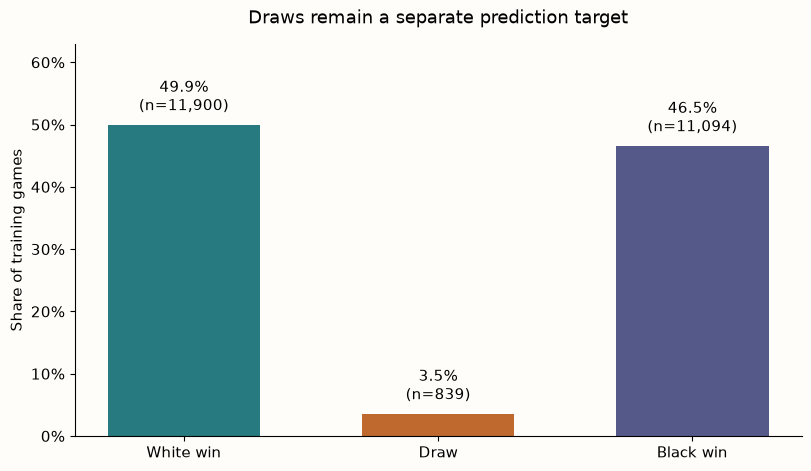

target,rating_gap,White win,Draw,Black win
0,≤−600,0.125000,0.000000,0.875000
1,−599 to\n−400,0.156463,0.013605,0.829932
2,−399 to\n−200,0.205962,0.046070,0.747967
3,−199 to\n0,0.459916,0.036747,0.503337
4,1 to\n200,0.538265,0.034121,0.427614
5,201 to\n400,0.713615,0.039906,0.246479
6,401 to\n600,0.881579,0.019737,0.098684
7,>600,0.930233,0.000000,0.069767


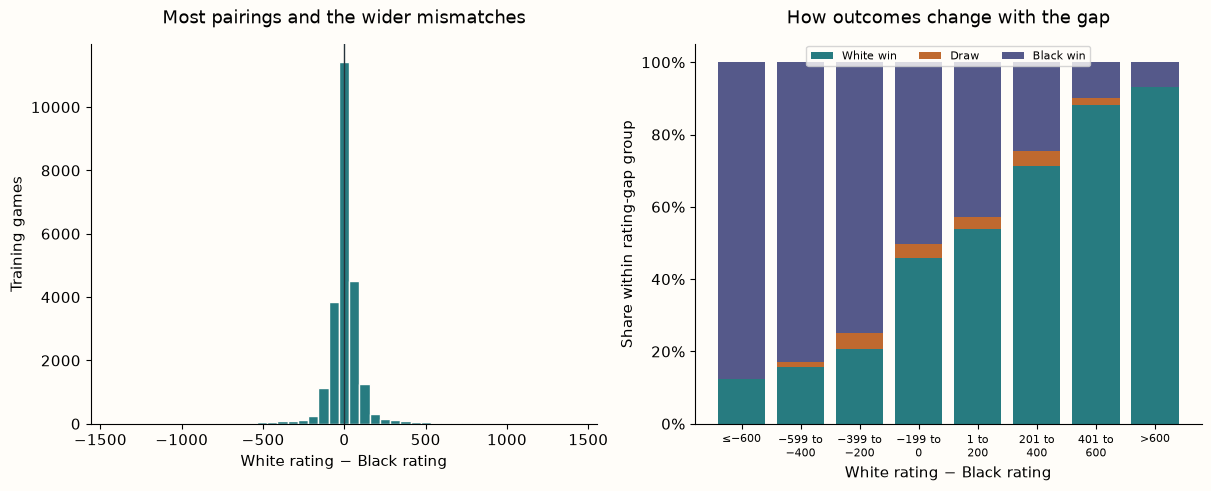

In [5]:
counts = y_train.value_counts().reindex(LABELS, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4.6), layout="constrained")
bars = ax.bar(NAMES, counts / len(train), color=COLORS, width=0.6)
ax.bar_label(bars, labels=[f"{n/len(train):.1%}\n(n={n:,})" for n in counts], padding=7)
ax.set(ylim=(0, max(counts/len(train))*1.26), ylabel="Share of training games", title="Draws remain a separate prediction target")
ax.yaxis.set_major_formatter(PercentFormatter(1))
save_chart(fig, "01_class_balance.png")

gap_bins = [-np.inf, -600, -400, -200, 0, 200, 400, 600, np.inf]
gap_labels = ["≤−600", "−599 to\n−400", "−399 to\n−200", "−199 to\n0", "1 to\n200", "201 to\n400", "401 to\n600", ">600"]
gap_group = pd.cut(train.elo_diff, gap_bins, labels=gap_labels)
gap_rates = pd.crosstab(gap_group, y_train, normalize="index").reindex(columns=LABELS, fill_value=0)
save_table(gap_rates.rename(columns=dict(zip(LABELS, NAMES))).rename_axis("rating_gap").reset_index(), "outcomes_by_gap.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
axes[0].hist(train.elo_diff, bins=45, color=COLORS[0], edgecolor="#fffdf9")
axes[0].axvline(0, color="#26333b", linewidth=1)
axes[0].set(title="Most pairings and the wider mismatches", xlabel="White rating − Black rating", ylabel="Training games")
bottom = np.zeros(len(gap_rates))
for label in LABELS:
    axes[1].bar(np.arange(len(gap_rates)), gap_rates[label], bottom=bottom, color=COLORS[label], label=NAMES[label])
    bottom += gap_rates[label].to_numpy()
axes[1].set_xticks(range(len(gap_rates)), gap_rates.index, fontsize=8)
axes[1].set(title="How outcomes change with the gap", xlabel="White rating − Black rating", ylabel="Share within rating-gap group")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=3, fontsize=8)
save_chart(fig, "02_rating_gap.png")

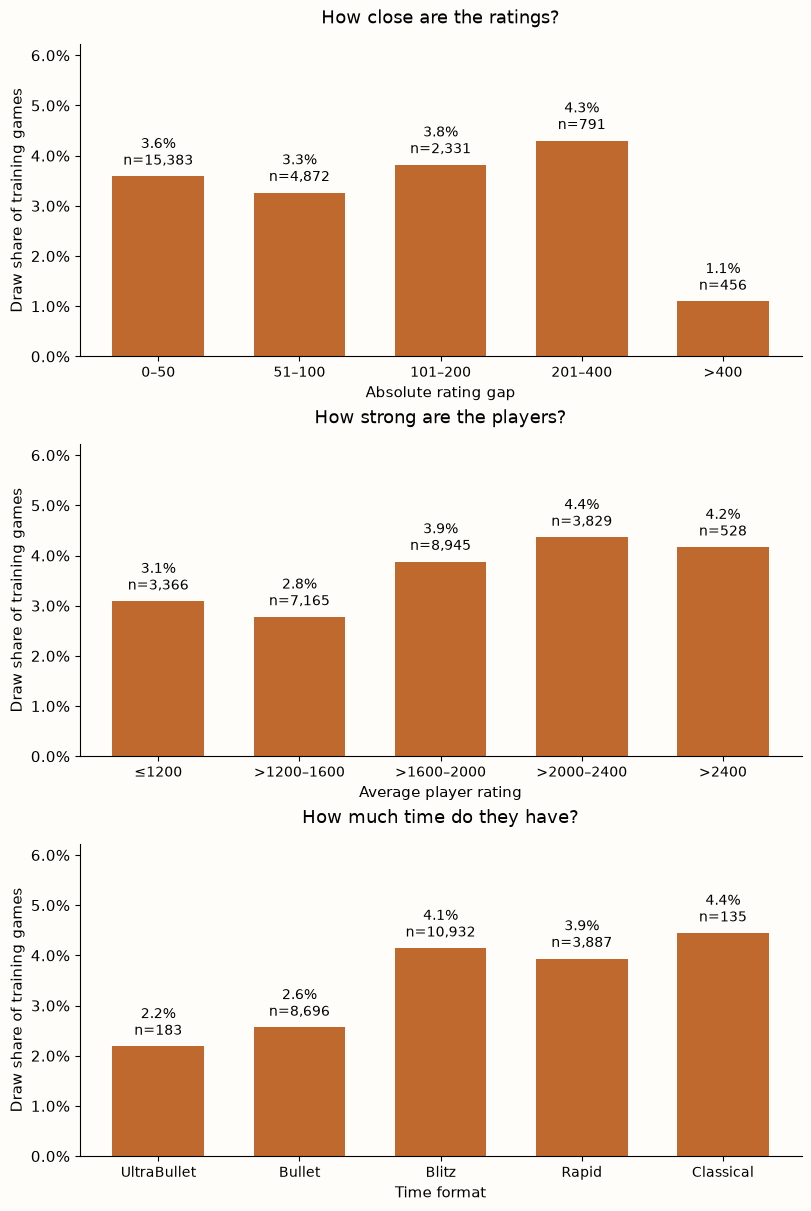

,games,draws,draw_rate
group,,,
0–50,15383,552,0.035884
51–100,4872,159,0.032635
101–200,2331,89,0.038181
201–400,791,34,0.042984
>400,456,5,0.010965


,games,draws,draw_rate
group,,,
≤1200,3366,104,0.030897
>1200–1600,7165,199,0.027774
>1600–2000,8945,347,0.038793
>2000–2400,3829,167,0.043615
>2400,528,22,0.041667


,games,draws,draw_rate
group,,,
UltraBullet,183,4,0.021858
Bullet,8696,223,0.025644
Blitz,10932,453,0.041438
Rapid,3887,153,0.039362
Classical,135,6,0.044444


In [6]:
def draw_summary(groups):
    values = pd.DataFrame({"group": groups, "draw": train.target.eq(1)})
    result = values.groupby("group", observed=True).draw.agg(["size", "sum", "mean"])
    return result.rename(columns={"size": "games", "sum": "draws", "mean": "draw_rate"})

draw_gap = draw_summary(pd.cut(train.abs_elo_diff, [-1, 50, 100, 200, 400, np.inf], labels=["0–50", "51–100", "101–200", "201–400", ">400"]))
draw_rating = draw_summary(pd.cut(train.average_rating, [-np.inf, 1200, 1600, 2000, 2400, np.inf], labels=["≤1200", ">1200–1600", ">1600–2000", ">2000–2400", ">2400"]))
draw_speed = draw_summary(train.speed)
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharey=True, layout="constrained")
draw_ylim = max(table.draw_rate.max() for table in [draw_gap, draw_rating, draw_speed]) * 1.4
for ax, table, title, xlabel, filename in zip(axes, [draw_gap, draw_rating, draw_speed],
        ["How close are the ratings?", "How strong are the players?", "How much time do they have?"],
        ["Absolute rating gap", "Average player rating", "Time format"],
        ["draws_by_gap.csv", "draws_by_rating.csv", "draws_by_speed.csv"]):
    bars = ax.bar(range(len(table)), table.draw_rate, color=COLORS[1], width=0.65)
    ax.bar_label(bars, labels=[f"{r.draw_rate:.1%}\nn={r.games:,}" for r in table.itertuples()], fontsize=10, padding=5)
    ax.set_xticks(range(len(table)), table.index, fontsize=10)
    ax.set(title=title, xlabel=xlabel, ylabel="Draw share of training games", ylim=(0, draw_ylim))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    table.reset_index().to_csv(OUT / filename, index=False)
save_chart(fig, "03_draw_patterns.png")
display(draw_gap)
display(draw_rating)
display(draw_speed)

## 5. Compare four model configurations on earlier validation games

I compare logistic regression and a random forest, each with ordinary class weights and `class_weight="balanced"`. Logistic regression provides an interpretable linear starting point; the forest can model nonlinear interactions. Balanced weights increase the loss assigned to minority-class mistakes. They may help draw recall, but they do not guarantee better precision or calibrated probabilities.

The pipeline learns scaling only from each training fold. Three expanding-window folds train on earlier starts and validate on later starts. I remove timestamp ties at each fold boundary. Folds contain comparable numbers of games, not necessarily equal elapsed time. The small grid tries C = 0.1, 1, or 10 for logistic regression; the forest tries depths 8 or 16 and minimum leaf sizes 5 or 25, with 150 trees. Fixed seeds make runs repeatable.

I select the configuration with the highest mean validation macro-F1, using lower validation log loss only to break a tie. Macro-F1 gives each class equal importance. The final test set does not choose the winner. All four configurations remain in the final comparison to show the weighting trade-off.

In [7]:
folds, fold_info = [], []
for number, (fit_idx, valid_idx) in enumerate(TimeSeriesSplit(n_splits=3).split(X_train), 1):
    # Keep equal start times on the same side of the boundary.
    valid_start = train.iloc[valid_idx].timestamp.min()
    fit_idx = fit_idx[(train.iloc[fit_idx].timestamp < valid_start).to_numpy()]
    assert set(y_train.iloc[fit_idx]) == set(LABELS) and set(y_train.iloc[valid_idx]) == set(LABELS)
    folds.append((fit_idx, valid_idx))
    fold_info.append({"fold": number, "fit_games": len(fit_idx), "validation_games": len(valid_idx),
        "fit_end": str(train.iloc[fit_idx].timestamp.max()), "validation_start": str(valid_start),
        "validation_end": str(train.iloc[valid_idx].timestamp.max())})
save_table(pd.DataFrame(fold_info), "validation_folds.csv")
scoring = {"macro_f1": make_scorer(f1_score, average="macro", labels=LABELS, zero_division=0), "log_loss": "neg_log_loss"}
models, choices, grid_rows = {}, [], []
for weight in [None, "balanced"]:
    suffix = "balanced" if weight else "ordinary"
    specs = [
        (f"Logistic ({suffix})", make_pipeline(StandardScaler(), LogisticRegression(class_weight=weight, max_iter=2000, solver="lbfgs")),
         {"logisticregression__C": [0.1, 1, 10]}),
        (f"Forest ({suffix})", make_pipeline(RandomForestClassifier(n_estimators=150, class_weight=weight, random_state=SEED, n_jobs=2)),
         {"randomforestclassifier__max_depth": [8, 16], "randomforestclassifier__min_samples_leaf": [5, 25]})]
    for name, estimator, grid in specs:
        search = GridSearchCV(estimator, grid, scoring=scoring, refit="macro_f1", cv=folds, n_jobs=1, error_score="raise")
        search.fit(X_train, y_train)
        models[name] = search.best_estimator_
        best = search.best_index_
        choices.append({"model": name, "cv_macro_f1": search.best_score_,
            "cv_log_loss": -search.cv_results_["mean_test_log_loss"][best], "parameters": str(search.best_params_)})
        for i, parameters in enumerate(search.cv_results_["params"]):
            grid_rows.append({"model": name, "parameters": str(parameters),
                "cv_macro_f1": search.cv_results_["mean_test_macro_f1"][i],
                "cv_f1_sd": search.cv_results_["std_test_macro_f1"][i],
                "cv_log_loss": -search.cv_results_["mean_test_log_loss"][i]})
        print(name, "validation macro-F1:", round(search.best_score_, 4), flush=True)
choice_table = pd.DataFrame(choices).sort_values(["cv_macro_f1", "cv_log_loss"], ascending=[False, True])
selected_name = choice_table.iloc[0].model
selected = models[selected_name]
save_table(choice_table, "model_selection.csv")
pd.DataFrame(grid_rows).to_csv(OUT / "grid_search.csv", index=False)
print("Selected before test evaluation:", selected_name)

,fold,fit_games,validation_games,fit_end,validation_start,validation_end
0,1,5959,5958,2026-09-01 00:47:27+00:00,2026-09-01 00:47:28+00:00,2026-09-01 01:36:54+00:00
1,2,11917,5958,2026-09-01 01:36:54+00:00,2026-09-01 01:36:56+00:00,2026-09-01 02:28:39+00:00
2,3,17875,5958,2026-09-01 02:28:39+00:00,2026-09-01 02:28:40+00:00,2026-09-01 03:21:18+00:00


Logistic (ordinary) validation macro-F1: 0.3576


Forest (ordinary) validation macro-F1: 0.3551


Logistic (balanced) validation macro-F1: 0.3198


Forest (balanced) validation macro-F1: 0.3523


,model,cv_macro_f1,cv_log_loss,parameters
0,Logistic (ordinary),0.357647,0.803419,{'logisticregression__C': 1}
1,Forest (ordinary),0.355140,0.810034,"{'randomforestclassifier__max_depth': 16, 'ran..."
3,Forest (balanced),0.352326,0.969570,"{'randomforestclassifier__max_depth': 16, 'ran..."
2,Logistic (balanced),0.319809,1.079726,{'logisticregression__C': 1}


Selected before test evaluation: Logistic (ordinary)


## 6. Evaluate the fixed models and two baselines

The majority baseline always predicts the most common training class. For probability metrics, its companion prediction is the training class-frequency vector. The higher-rated rule predicts White if White's rating is higher, Black if Black's is higher, and the training majority class when ratings tie. It has no draw prediction and no probability model, so I do not assign it invented log-loss or ROC-AUC values.

Precision asks how many predictions of a class were right; recall asks how many actual examples of that class were found. F1 balances the two. Log loss penalizes overconfident wrong probabilities. One-vs-rest ROC-AUC measures how well each class's probability ranks that class against the others; it does not show precision at the chosen prediction threshold. Accuracy alone can hide missed draws. Predictions use the largest class probability without tuning thresholds on the test set.

In [8]:
predictions, probabilities, metric_rows, class_rows = {}, {}, [], []
dummy = DummyClassifier(strategy="prior").fit(X_train, y_train)
predictions["Majority / training priors"] = dummy.predict(X_test)
probabilities["Majority / training priors"] = dummy.predict_proba(X_test)
majority = int(y_train.value_counts().idxmax())
predictions["Higher-rated rule"] = np.where(test.elo_diff > 0, 0, np.where(test.elo_diff < 0, 2, majority))
for name, model in models.items():
    assert list(model.classes_) == LABELS
    probabilities[name] = model.predict_proba(X_test)
    predictions[name] = model.predict(X_test)

for name, prediction in predictions.items():
    report = classification_report(y_test, prediction, labels=LABELS, target_names=NAMES, output_dict=True, zero_division=0)
    row = {"model": name, "accuracy": accuracy_score(y_test, prediction),
        "macro_f1": f1_score(y_test, prediction, labels=LABELS, average="macro", zero_division=0),
        "draw_precision": report["Draw"]["precision"], "draw_recall": report["Draw"]["recall"], "draw_f1": report["Draw"]["f1-score"], "log_loss": np.nan}
    if name in probabilities:
        proba = probabilities[name]
        assert np.allclose(proba.sum(axis=1), 1)
        row["log_loss"] = log_loss(y_test, proba, labels=LABELS)
    for label, class_name in enumerate(NAMES):
        class_rows.append({"model": name, "class": class_name, **report[class_name],
            "roc_auc_ovr": roc_auc_score(y_test.eq(label), probabilities[name][:, label]) if name in probabilities else np.nan})
    metric_rows.append(row)
metrics = pd.DataFrame(metric_rows)
per_class = pd.DataFrame(class_rows)
save_table(metrics, "test_metrics.csv")
save_table(per_class, "per_class_metrics.csv")
selected_pred = predictions[selected_name]
selected_proba = probabilities[selected_name]

,model,accuracy,macro_f1,draw_precision,draw_recall,draw_f1,log_loss
0,Majority / training priors,0.513845,0.226287,0.000000,0.000000,0.000000,0.822652
1,Higher-rated rule,0.530794,0.359843,0.000000,0.000000,0.000000,NaN
2,Logistic (ordinary),0.534989,0.350606,0.000000,0.000000,0.000000,0.807869
3,Forest (ordinary),0.526934,0.351403,0.000000,0.000000,0.000000,0.813355
4,Logistic (balanced),0.352912,0.311550,0.048359,0.516129,0.088433,1.086407
5,Forest (balanced),0.426414,0.337043,0.044818,0.221198,0.074534,0.983816


,model,class,precision,recall,f1-score,support,roc_auc_ovr
0,Majority / training priors,White win,0.513845,1.000000,0.678860,3062.0,0.500000
1,Majority / training priors,Draw,0.000000,0.000000,0.000000,217.0,0.500000
2,Majority / training priors,Black win,0.000000,0.000000,0.000000,2680.0,0.500000
3,Higher-rated rule,White win,0.561064,0.558132,0.559594,3062.0,NaN
4,Higher-rated rule,Draw,0.000000,0.000000,0.000000,217.0,NaN
5,Higher-rated rule,Black win,0.499142,0.542537,0.519936,2680.0,NaN
6,Logistic (ordinary),White win,0.545250,0.712280,0.617672,3062.0,0.571994
7,Logistic (ordinary),Draw,0.000000,0.000000,0.000000,217.0,0.605508
8,Logistic (ordinary),Black win,0.514038,0.375746,0.434145,2680.0,0.572329
9,Forest (ordinary),White win,0.543912,0.649249,0.591931,3062.0,0.555772


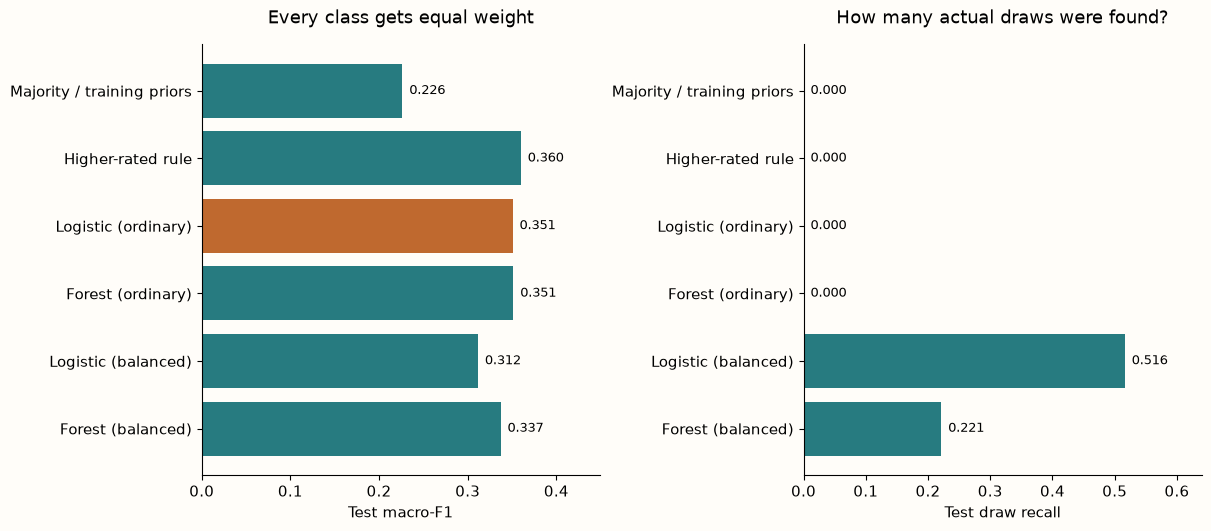

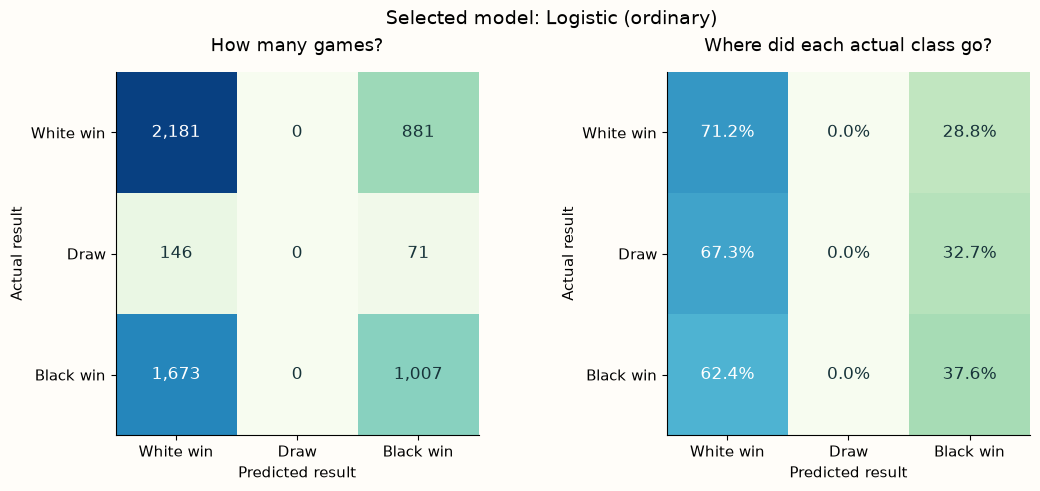

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), layout="constrained")
for ax, column, title in zip(axes, ["macro_f1", "draw_recall"], ["Every class gets equal weight", "How many actual draws were found?"]):
    bars = ax.barh(metrics.model, metrics[column], color=[COLORS[1] if n == selected_name else COLORS[0] for n in metrics.model])
    ax.bar_label(bars, fmt="%.3f", padding=5, fontsize=9)
    ax.set(xlabel="Test macro-F1" if column == "macro_f1" else "Test draw recall", title=title, xlim=(0, max(metrics[column])*1.22 + 0.01))
    ax.invert_yaxis()
save_chart(fig, "04_model_comparison.png")

matrix = confusion_matrix(y_test, selected_pred, labels=LABELS)
pd.DataFrame(matrix, index=NAMES, columns=NAMES).to_csv(OUT / "confusion_matrix.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), layout="constrained")
for ax, values, title, percent in zip(axes, [matrix, matrix / matrix.sum(axis=1, keepdims=True)], ["How many games?", "Where did each actual class go?"], [False, True]):
    ax.imshow(values, cmap="GnBu", vmin=0, vmax=1 if percent else matrix.max())
    for i in LABELS:
        for j in LABELS:
            value = values[i, j]
            label = f"{value:.1%}" if percent else f"{value:,}"
            ax.text(j, i, label, ha="center", va="center", color="white" if value > (0.55 if percent else matrix.max()*0.55) else "#18343a", fontsize=12)
    ax.set_xticks(LABELS, NAMES)
    ax.set_yticks(LABELS, NAMES)
    ax.set(xlabel="Predicted result", ylabel="Actual result", title=title)
fig.suptitle(f"Selected model: {selected_name}", fontsize=14)
save_chart(fig, "05_confusion_matrix.png")

## 7. Compare expected scores and probability calibration

A draw earns half a point. The model's expected score for White is P(White win) + 0.5 × P(Draw). I compare it with the simple Elo-style expression 1 / (1 + 10 ** (−rating_gap / 400)). Lichess uses Glicko-2, so this expression is a reference curve, not Lichess's full rating algorithm and not a three-class probability distribution.

For each reference or model, I group test expected scores into ten fixed intervals, then compare the mean prediction with the actual mean score (win = 1, draw = 0.5, loss = 0). Mean squared error summarizes the score prediction, not three-class Brier loss. I show draw reliability in six equal-count probability groups because the draw probabilities occupy a narrow range. This display choice does not change the model or its scores. Small bins and repeated players limit both plots; I do not recalibrate or retune using these test results.

,model,score_mse
0,Elo-style reference,0.235914
1,Logistic (ordinary),0.234423
2,Forest (ordinary),0.236649
3,Logistic (balanced),0.235460
4,Forest (balanced),0.238035


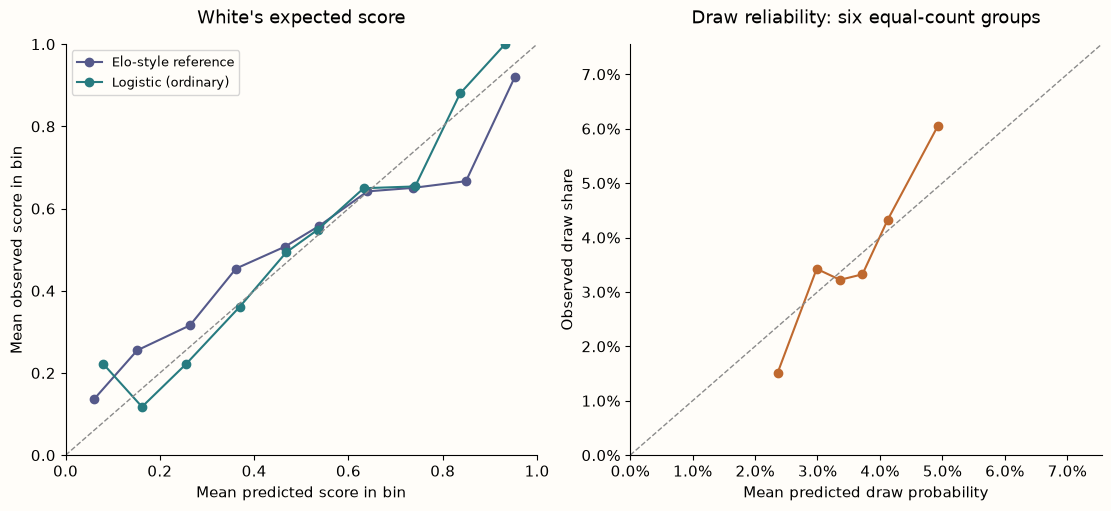

In [10]:
actual_score = y_test.map({0: 1.0, 1: 0.5, 2: 0.0}).to_numpy()
expected = {"Elo-style reference": 1 / (1 + 10 ** (-test.elo_diff.to_numpy() / 400))}
for name in models:
    expected[name] = probabilities[name][:, 0] + 0.5 * probabilities[name][:, 1]
score_errors = pd.DataFrame([{"model": name, "score_mse": np.mean((values - actual_score)**2)} for name, values in expected.items()])
save_table(score_errors, "expected_score_errors.csv")

def reliability(predicted, actual, quantiles=False):
    table = pd.DataFrame({"predicted": predicted, "actual": actual})
    table["bin"] = pd.qcut(table.predicted, 6, duplicates="drop") if quantiles else pd.cut(table.predicted, np.linspace(0, 1, 11), include_lowest=True)
    return table.groupby("bin", observed=True).agg(predicted=("predicted", "mean"), observed=("actual", "mean"), games=("actual", "size")).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 5), layout="constrained")
calibration_tables = []
for name, color in [("Elo-style reference", COLORS[2]), (selected_name, COLORS[0])]:
    table = reliability(expected[name], actual_score)
    table["model"] = name
    calibration_tables.append(table)
    axes[0].plot(table.predicted, table.observed, "o-", label=name, color=color)
axes[0].set(title="White's expected score", xlabel="Mean predicted score in bin", ylabel="Mean observed score in bin", xlim=(0, 1), ylim=(0, 1))
axes[0].legend(fontsize=9)
draw_calibration = reliability(selected_proba[:, 1], y_test.eq(1).to_numpy(), quantiles=True)
axes[1].plot(draw_calibration.predicted, draw_calibration.observed, "o-", color=COLORS[1])
draw_limit = max(draw_calibration.predicted.max(), draw_calibration.observed.max()) * 1.25
axes[1].set(title="Draw reliability: six equal-count groups", xlabel="Mean predicted draw probability", ylabel="Observed draw share", xlim=(0, draw_limit), ylim=(0, draw_limit))
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
for ax in axes:
    ax.plot([0, 1], [0, 1], "--", color="#8b8b8b", linewidth=1)
save_chart(fig, "06_calibration.png")
pd.concat(calibration_tables).to_csv(OUT / "expected_score_calibration.csv", index=False)
draw_calibration.to_csv(OUT / "draw_calibration.csv", index=False)

## 8. Interpret coefficients, feature groups, and errors

I inspect the ordinary logistic model's coefficients. A coefficient describes a change in a class's logit per training standard deviation, not a direct percentage-point change in probability. Multinomial probabilities depend on all three logits. The signed and absolute gaps are related, so coefficients are descriptive, not causal.

For the selected model, I permute feature groups on the test set and measure the increase in one-vs-rest binary log loss for each class. I move signed gap and absolute gap together to preserve abs(gap), and move both clock features together. Larger increases mean the model relied more on that group for its probabilities. This avoids presenting the forest's global impurity importance as a draw-specific explanation. Shuffling can still create unusual combinations, so I report five repeats and their standard deviation, not a causal claim or confidence interval.

Finally, I examine the actual draws and the predictions they received. This can locate weak spots but cannot explain the moves that caused a particular draw.

,feature,White win,Draw,Black win
0,elo_diff,0.231068,-0.015915,-0.215153
1,abs_elo_diff,-0.008433,0.006616,0.001817
2,average_rating,-0.061279,0.136711,-0.075431
3,log_base_seconds,-0.081015,0.160397,-0.079382
4,log_increment_seconds,0.009769,0.010086,-0.019855


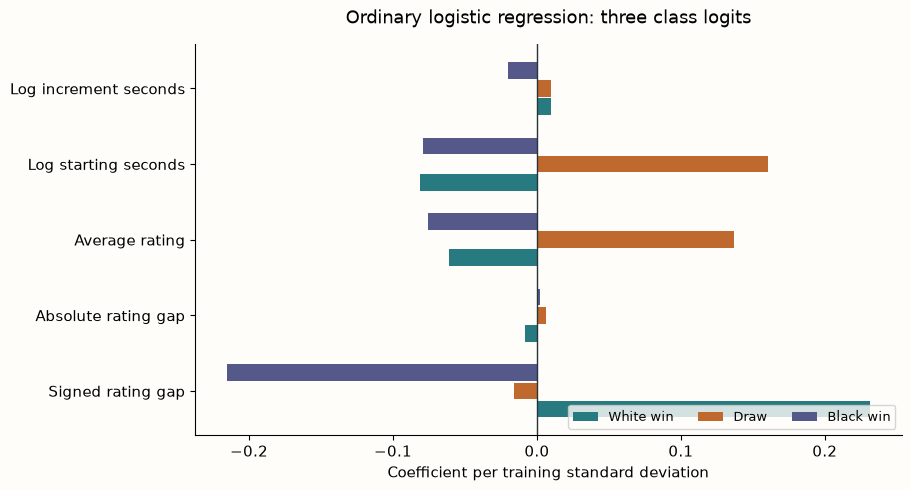

,group,class,mean,std
0,Average rating,Black win,0.000058,0.000166
1,Average rating,Draw,0.001328,0.000313
2,Average rating,White win,-0.000002,0.000032
3,Clock (base + increment),Black win,-0.000110,0.000215
4,Clock (base + increment),Draw,0.003053,0.000510
5,Clock (base + increment),White win,-0.000329,0.000137
6,Rating gap (signed + absolute),Black win,0.028455,0.001440
7,Rating gap (signed + absolute),Draw,0.000447,0.000225
8,Rating gap (signed + absolute),White win,0.029562,0.000672


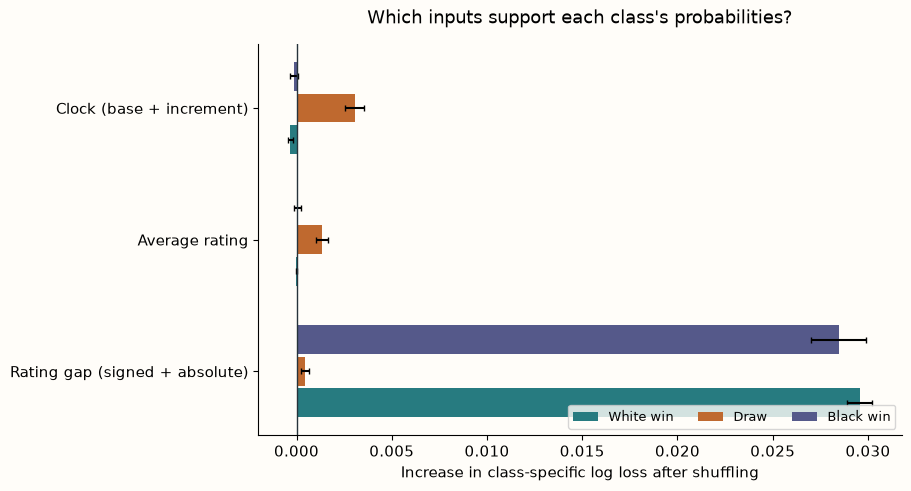

In [11]:
logistic = models["Logistic (ordinary)"].named_steps["logisticregression"]
coefficients = pd.DataFrame(logistic.coef_.T, index=features, columns=NAMES)
save_table(coefficients.rename_axis("feature").reset_index(), "logistic_coefficients.csv")
fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
positions = np.arange(len(features))
for label in LABELS:
    ax.barh(positions + (label-1)*0.24, coefficients.iloc[:, label], height=0.22, color=COLORS[label], label=NAMES[label])
ax.axvline(0, color="#26333b", linewidth=1)
ax.set_yticks(positions, ["Signed rating gap", "Absolute rating gap", "Average rating", "Log starting seconds", "Log increment seconds"])
ax.set(xlabel="Coefficient per training standard deviation", title="Ordinary logistic regression: three class logits")
ax.legend(ncol=3, loc="lower right", fontsize=9)
save_chart(fig, "07_coefficients.png")

groups = {"Rating gap (signed + absolute)": ["elo_diff", "abs_elo_diff"], "Average rating": ["average_rating"], "Clock (base + increment)": ["log_base_seconds", "log_increment_seconds"]}
importance_rows = []
rng = np.random.default_rng(SEED)
base_loss = [log_loss(y_test.eq(label), selected_proba[:, label], labels=[False, True]) for label in LABELS]
for group, columns in groups.items():
    for repeat in range(5):
        shuffled = X_test.copy()
        order = rng.permutation(len(shuffled))
        shuffled.loc[:, columns] = shuffled[columns].to_numpy()[order]
        shuffled_proba = selected.predict_proba(shuffled)
        for label in LABELS:
            importance_rows.append({"group": group, "class": NAMES[label], "repeat": repeat,
                "loss_increase": log_loss(y_test.eq(label), shuffled_proba[:, label], labels=[False, True]) - base_loss[label]})
importance = pd.DataFrame(importance_rows).groupby(["group", "class"]).loss_increase.agg(["mean", "std"]).reset_index()
save_table(importance, "class_feature_importance.csv")
fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
for label, class_name in enumerate(NAMES):
    table = importance.loc[importance["class"].eq(class_name)].set_index("group").reindex(groups)
    ax.barh(np.arange(len(groups)) + (label-1)*0.24, table["mean"], xerr=table["std"], height=0.22, label=class_name, color=COLORS[label], capsize=2)
ax.axvline(0, color="#26333b", linewidth=1)
ax.set_yticks(np.arange(len(groups)), list(groups))
ax.set(xlabel="Increase in class-specific log loss after shuffling", title="Which inputs support each class's probabilities?")
ax.legend(ncol=3, loc="lower right", fontsize=9)
save_chart(fig, "08_class_importance.png")

In [12]:
errors = test[["timestamp", "elo_diff", "abs_elo_diff", "average_rating", "speed", "target"]].copy()
errors["prediction"] = selected_pred
errors["draw_probability"] = selected_proba[:, 1]
errors["white_probability"] = selected_proba[:, 0]
errors["black_probability"] = selected_proba[:, 2]
actual_draws = errors.loc[errors.target.eq(1)]
draw_errors = actual_draws.groupby("prediction").agg(games=("target", "size"), mean_abs_gap=("abs_elo_diff", "mean"), mean_rating=("average_rating", "mean"), mean_draw_probability=("draw_probability", "mean")).reindex(LABELS)
draw_errors.index = NAMES
draw_errors["games"] = draw_errors.games.fillna(0).astype(int)
save_table(draw_errors.rename_axis("predicted_result").reset_index(), "actual_draw_errors.csv")
save_table(actual_draws.groupby("speed", observed=True).agg(actual_draws=("target", "size"), found=("prediction", lambda values: int(values.eq(1).sum())), mean_draw_probability=("draw_probability", "mean")).reset_index(), "draw_errors_by_speed.csv")
errors.to_csv(OUT / "test_predictions.csv", index=False)
unseen = ~test_seen
if unseen.sum() and set(y_test[unseen]) == set(LABELS):
    print("Sensitivity check: games with neither player seen in training")
    print("Games:", int(unseen.sum()), "macro-F1:", round(f1_score(y_test[unseen], selected_pred[unseen], average="macro", labels=LABELS, zero_division=0), 4))

,predicted_result,games,mean_abs_gap,mean_rating,mean_draw_probability
0,White win,146,34.876712,1706.342466,0.038851
1,Draw,0,NaN,NaN,NaN
2,Black win,71,67.197183,1726.345070,0.040152


,speed,actual_draws,found,mean_draw_probability
0,Bullet,47,0,0.032057
1,Blitz,118,0,0.039403
2,Rapid,50,0,0.044539
3,Classical,2,0,0.069919


Sensitivity check: games with neither player seen in training
Games: 3225 macro-F1: 0.3454


## 9. What this experiment can and cannot establish

The test results describe this sampled window, with this split and these five features. They do not establish performance on future months, other sites, tournament chess, or previously unseen players. BOT tags remove known bot accounts, not undisclosed engine use. Player ratings omit rating deviation and volatility, so equal ratings can have different uncertainty. Pool differences across time formats also matter.

Only a small portion of games may be draws. A respectable overall accuracy or ROC-AUC can coexist with poor draw recall or precision. Class balancing changes the objective and can overstate draw probabilities. The sample preserves the observed outcome distribution; I do not oversample the test set or remove draws to improve accuracy.

A wrong prediction here mostly misleads a probability display or expected-score estimate. The model is not a cheating detector, a substitute for a chess engine, or a basis for judging a person's ability. A useful next experiment would sample multiple days/months, record finish times, evaluate player-disjoint or future-period data, and fit any calibration step only inside training validation.

The website explains the measured results. No personally experienced motivation, manual review, or classroom learning is claimed on the author's behalf.

In [13]:
summary = {
    "raw_rows": len(raw), "clean_rows": len(df), "train_rows": len(train), "test_rows": len(test),
    "start": str(df.timestamp.min()), "end": str(df.timestamp.max()),
    "train_end": str(train.timestamp.max()), "test_start": str(test.timestamp.min()),
    "selected_model": selected_name, "test_seen_player_share": float(test_seen.mean()),
    "unseen_test_games": int(unseen.sum()),
    "unseen_macro_f1": float(f1_score(y_test[unseen], selected_pred[unseen], average="macro", labels=LABELS, zero_division=0)) if unseen.sum() and set(y_test[unseen]) == set(LABELS) else None,
    "wide_gap_games": int(df.abs_elo_diff.gt(1000).sum()),
    "rating_min": float(df[["white_rating", "black_rating"]].min().min()),
    "rating_max": float(df[["white_rating", "black_rating"]].max().max()),
    "features": features, "seed": SEED,
    "python": platform.python_version(),
    "packages": {name: importlib.metadata.version(name) for name in ["numpy", "pandas", "matplotlib", "scikit-learn", "requests", "zstandard", "nbformat", "nbclient", "ipykernel"]},
}
(OUT / "run_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("Finished. Tables are in analysis/chess/results; charts are in assets/images/chess.")
display(summary)

Finished. Tables are in analysis/chess/results; charts are in assets/images/chess.


{'raw_rows': 30000,
 'clean_rows': 29792,
 'train_rows': 23833,
 'test_rows': 5959,
 'start': '2026-09-01 00:00:00+00:00',
 'end': '2026-09-01 04:13:48+00:00',
 'train_end': '2026-09-01 03:21:18+00:00',
 'test_start': '2026-09-01 03:21:19+00:00',
 'selected_model': 'Logistic (ordinary)',
 'test_seen_player_share': 0.4588018123846283,
 'unseen_test_games': 3225,
 'unseen_macro_f1': 0.3453792708252746,
 'wide_gap_games': 22,
 'rating_min': 400.0,
 'rating_max': 3211.0,
 'features': ['elo_diff',
  'abs_elo_diff',
  'average_rating',
  'log_base_seconds',
  'log_increment_seconds'],
 'seed': 2301,
 'python': '3.12.14',
 'packages': {'numpy': '2.5.3',
  'pandas': '3.0.6',
  'matplotlib': '3.11.2',
  'scikit-learn': '1.9.1',
  'requests': '2.34.2',
  'zstandard': '0.25.0',
  'nbformat': '5.11.1',
  'nbclient': '0.11.0',
  'ipykernel': '7.4.0'}}

## References

Breiman, L. (2001). Random forests. *Machine Learning, 45*, 5–32. https://doi.org/10.1023/A:1010933404324

Glickman, M. E. (2022, March 22). *Example of the Glicko-2 system*. https://www.glicko.net/glicko/glicko2.pdf

Lichess. (n.d.). *Lichess open database*. Retrieved October 5, 2026, from https://database.lichess.org/

Lichess. (n.d.). *Chess rating systems*. https://lichess.org/page/rating-systems

Lichess. (n.d.). *Frequently asked questions*. https://lichess.org/faq

Scikit-learn developers. (n.d.). *LogisticRegression*. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Scikit-learn developers. (n.d.). *RandomForestClassifier*. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Scikit-learn developers. (n.d.). *TimeSeriesSplit*. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html